# 🐦 Twitter Sentiment Analysis
### Análisis de Sentimientos con NLP, Machine Learning y Deep Learning

---

> **Objetivo:** Comprender cómo las máquinas procesan el lenguaje humano, representan palabras como números, y aprenden a detectar emociones en textos de Twitter.

**Dataset:** Twitter Entity Sentiment Analysis (Kaggle)  
**Herramientas:** Python · pandas · scikit-learn · TensorFlow/Keras · matplotlib · seaborn

---

## 🗺️ Estructura del Proyecto

| # | Sección | Concepto clave |
|---|---------|----------------|
| 1 | Instalación y configuración | Setup |
| 2 | Exploración del dataset (EDA) | Entender los datos |
| 3 | ¿Qué es NLP? | Conceptos fundamentales |
| 4 | Word Embeddings | Palabras como vectores |
| 5 | Preprocesamiento de texto | Limpiar y transformar |
| 6 | Modelos clásicos de ML | SVM, Random Forest |
| 7 | Redes Neuronales Recurrentes | LSTM y GRU |
| 8 | Atención y Transformers | Modelos modernos |
| 9 | Evaluación y métricas | Medir el rendimiento |
| 10 | Visualizaciones avanzadas | Entender los resultados |
| 11 | Aplicación empresarial | NLP en el mundo real |
| 12 | Conclusiones | Qué aprendimos |


---
## 📦 Sección 1 — Instalación y Configuración

Primero instalamos las librerías que no vienen por defecto en Colab.

In [12]:
# ─── Instalación de librerías adicionales ───────────────────────────────────
!pip install wordcloud contractions -q

import nltk
# punkt_tab es requerido en versiones recientes de NLTK (3.8+)
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)   # ← línea nueva
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',    quiet=True)   # ← necesario para WordNetLemmatizer

print('✅ Librerías instaladas correctamente')

✅ Librerías instaladas correctamente


In [2]:
# ─── Importación de todas las librerías del proyecto ────────────────────────

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP clásico
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions

# Machine Learning clásico
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout,
                                      Bidirectional, SimpleRNN, GlobalMaxPooling1D,
                                      Input, Attention)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Reducción dimensional para visualizar embeddings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Fijar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Todas las librerías cargadas')
print(f'   TensorFlow version: {tf.__version__}')

✅ Todas las librerías cargadas
   TensorFlow version: 2.20.0


---
## 🔍 Sección 2 — Exploración del Dataset (EDA)

### ¿Qué datos tenemos?

Antes de entrenar cualquier modelo, **debemos entender profundamente nuestros datos**. Este paso se llama **EDA (Exploratory Data Analysis)**.

El dataset contiene tweets etiquetados manualmente con cuatro categorías de sentimiento:  
- **Positive** 😊 → El tweet expresa emociones positivas sobre la entidad  
- **Negative** 😠 → El tweet expresa emociones negativas  
- **Neutral** 😐 → El tweet no tiene carga emocional clara  
- **Irrelevant** 🔕 → El tweet no habla realmente de la entidad  


In [4]:
# ─── Carga del dataset ──────────────────────────────────────────────────────
# Nota: sube los archivos twitter_training.csv y twitter_validation.csv
# al entorno de Colab o móntalos desde Google Drive.

# Opción 1 — Subida directa (botón de archivos en Colab)
# from google.colab import files
# uploaded = files.upload()

# Opción 2 — Desde Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/twitter_training.csv'

from google.colab import files
print("Suba twitter_training")
uploaded_twitter_training = files.upload()

print("Suba twitter_validation")
uploaded_twitter_validation = files.upload()

TRAIN_PATH = 'twitter_training.csv'
VAL_PATH   = 'twitter_validation.csv'

# Columnas del dataset
COLS = ['tweet_id', 'entity', 'sentiment', 'text']

train_df = pd.read_csv(TRAIN_PATH, header=None, names=COLS)
val_df   = pd.read_csv(VAL_PATH,   header=None, names=COLS)

print(f'📊 Entrenamiento : {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas')
print(f'📊 Validación    : {val_df.shape[0]:,} filas × {val_df.shape[1]} columnas')
train_df.head(10)

Suba twitter_training


Saving twitter_training.csv to twitter_training.csv
Suba twitter_validation


Saving twitter_validation.csv to twitter_validation.csv
📊 Entrenamiento : 74,682 filas × 4 columnas
📊 Validación    : 1,000 filas × 4 columnas


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [5]:
# ─── Información general del dataset ────────────────────────────────────────
print('='*55)
print('INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO')
print('='*55)
train_df.info()
print()
print('Valores nulos por columna:')
print(train_df.isnull().sum())
print()
print('Tipos de datos únicos:')
print(train_df.dtypes)

INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

Valores nulos por columna:
tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

Tipos de datos únicos:
tweet_id      int64
entity       object
sentiment    object
text         object
dtype: object


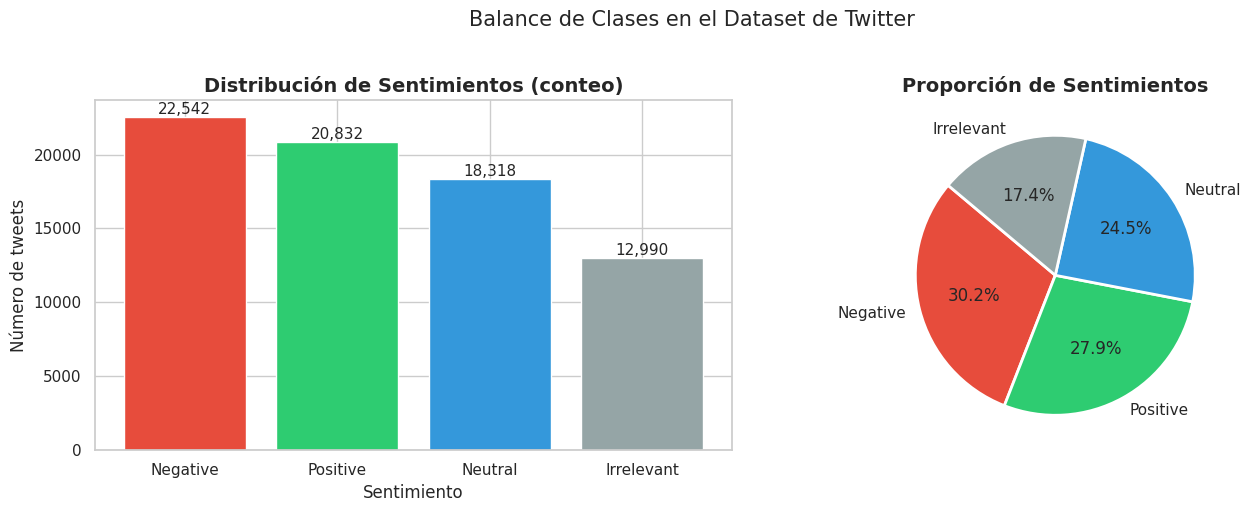


💡 INTERPRETACIÓN:
   El dataset está RELATIVAMENTE BALANCEADO, lo cual es ideal para
   el entrenamiento. En datos desbalanceados, el modelo aprende a
   predecir siempre la clase mayoritaria sin aprender nada real.


In [6]:
# ─── Distribución de sentimientos ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {
    'Positive':   '#2ecc71',
    'Negative':   '#e74c3c',
    'Neutral':    '#3498db',
    'Irrelevant': '#95a5a6'
}

# Gráfico de barras
counts = train_df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[palette[s] for s in counts.index], edgecolor='white')
axes[0].set_title('Distribución de Sentimientos (conteo)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Número de tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Gráfico de pastel
axes[1].pie(counts.values, labels=counts.index,
            colors=[palette[s] for s in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Proporción de Sentimientos', fontsize=14, fontweight='bold')

plt.suptitle('Balance de Clases en el Dataset de Twitter', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('   El dataset está RELATIVAMENTE BALANCEADO, lo cual es ideal para')
print('   el entrenamiento. En datos desbalanceados, el modelo aprende a')
print('   predecir siempre la clase mayoritaria sin aprender nada real.')

Estadísticas de longitud de tweets:
       text_length  word_count
count      74682.0     74682.0
mean         107.8        19.1
std           79.8        14.5
min            0.0         0.0
25%           45.0         8.0
50%           90.0        15.0
75%          152.0        27.0
max          957.0       198.0


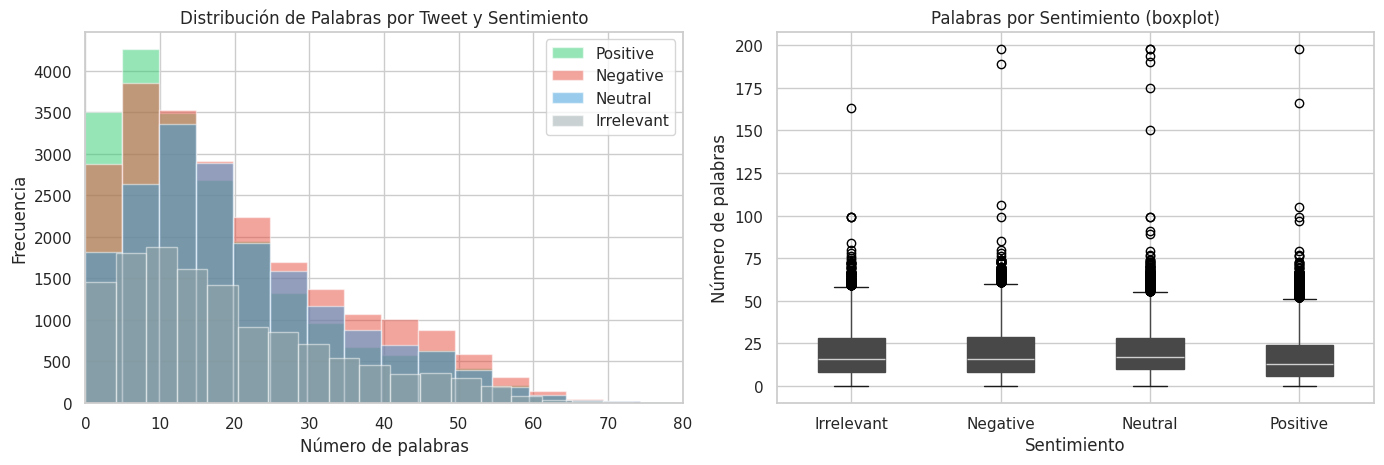


💡 Los tweets negativos tienden a ser un poco más largos —
   las personas suelen escribir más cuando se quejan.


In [7]:
# ─── Análisis de longitud de textos ─────────────────────────────────────────
train_df['text_length'] = train_df['text'].fillna('').apply(len)
train_df['word_count']  = train_df['text'].fillna('').apply(lambda x: len(str(x).split()))

print('Estadísticas de longitud de tweets:')
print(train_df[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment, color in palette.items():
    subset = train_df[train_df['sentiment'] == sentiment]['word_count']
    axes[0].hist(subset, bins=40, alpha=0.5, color=color, label=sentiment)
axes[0].set_title('Distribución de Palabras por Tweet y Sentimiento')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].set_xlim(0, 80)

train_df.boxplot(column='word_count', by='sentiment', ax=axes[1],
                 patch_artist=True)
axes[1].set_title('Palabras por Sentimiento (boxplot)')
axes[1].set_xlabel('Sentimiento')
axes[1].set_ylabel('Número de palabras')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('\n💡 Los tweets negativos tienden a ser un poco más largos —')
print('   las personas suelen escribir más cuando se quejan.')

In [8]:
# ─── Ejemplos reales por categoría ──────────────────────────────────────────
print('='*65)
print('EJEMPLOS REALES DE TWEETS POR CATEGORÍA')
print('='*65)

for sentiment in ['Positive', 'Negative', 'Neutral', 'Irrelevant']:
    examples = train_df[train_df['sentiment'] == sentiment]['text'].dropna().head(3)
    icon = {'Positive':'😊','Negative':'😠','Neutral':'😐','Irrelevant':'🔕'}[sentiment]
    print(f'\n{icon} {sentiment.upper()}:')
    for i, tweet in enumerate(examples, 1):
        print(f'  {i}. {str(tweet)[:120]}')

EJEMPLOS REALES DE TWEETS POR CATEGORÍA

😊 POSITIVE:
  1. im getting on borderlands and i will murder you all ,
  2. I am coming to the borders and I will kill you all,
  3. im getting on borderlands and i will kill you all,

😠 NEGATIVE:
  1. the biggest dissappoinment in my life came out a year ago fuck borderlands 3
  2. The biggest disappointment of my life came a year ago.
  3. The biggest disappointment of my life came a year ago.

😐 NEUTRAL:
  1. Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  
  2. Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it / RMTrgF
  3. Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dfr.it / RMTrgF

🔕 IRRELEVANT:
  1. Appreciate the (sonic) concepts / praxis Valenzuela and Landa-Posas thread together in this talk: multimodal listening, 
  2. Appreciate the (sound) concepts / practices that Valenzuela and Landa-Posas combine in this lecture: mu

/tmp/ipykernel_10374/3620636731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entities.values, y=top_entities.index,


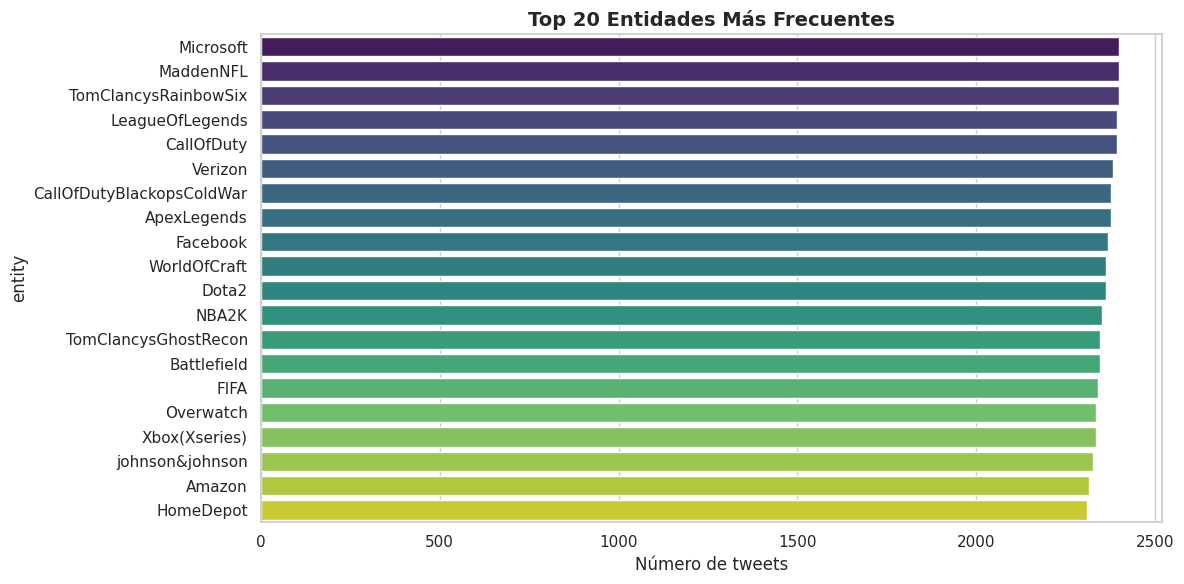


Total de entidades únicas: 32
El dataset cubre marcas, videojuegos, empresas tecnológicas y plataformas.


In [9]:
# ─── Entidades más frecuentes ────────────────────────────────────────────────
top_entities = train_df['entity'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_entities.values, y=top_entities.index,
            palette='viridis')
plt.title('Top 20 Entidades Más Frecuentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de tweets')
plt.tight_layout()
plt.show()

print(f'\nTotal de entidades únicas: {train_df["entity"].nunique()}')
print('El dataset cubre marcas, videojuegos, empresas tecnológicas y plataformas.')

---
## 🧠 Sección 3 — ¿Qué es NLP? Conceptos Fundamentales

### El problema central: las máquinas no entienden palabras

Un computador trabaja exclusivamente con números. Para que pueda "entender" texto, necesitamos un proceso de **transformación**: convertir palabras en representaciones matemáticas que capturen su significado.

```
Texto → Tokens → Números → Vectores → Red Neuronal → Predicción
```

### Pipeline de NLP paso a paso

| Paso | Nombre | Qué hace | Ejemplo |
|------|--------|----------|---------|
| 1 | Tokenización | Divide el texto en unidades (tokens) | `"I love cats"` → `["I", "love", "cats"]` |
| 2 | Lowercasing | Convierte a minúsculas | `"Twitter"` → `"twitter"` |
| 3 | Eliminación de stopwords | Quita palabras sin significado | `"is", "the", "a"` → eliminados |
| 4 | Stemming | Reduce a la raíz de la palabra | `"running"` → `"run"` |
| 5 | Lemmatización | Reduce a la forma base real | `"better"` → `"good"` |
| 6 | Vectorización | Convierte tokens en números | `"love"` → `[0.2, -0.5, ...]` |

### Bag of Words vs TF-IDF vs Embeddings

**Bag of Words (BoW):** La forma más simple. Cuenta cuántas veces aparece cada palabra. No considera el orden ni el significado.
```
"I love this product" → [1, 1, 1, 1, 0, 0, 0, ...]
                          I  love this product hate bad...
```

**TF-IDF:** Mejora BoW pesando las palabras según su importancia. Palabras muy comunes como "the" tienen menos peso.

**Embeddings:** La forma más poderosa. Cada palabra se representa como un vector denso de 100–300 números que captura *relaciones semánticas*. Explicado en detalle en la siguiente sección.


In [13]:
# ─── Demostración práctica de conceptos de NLP ──────────────────────────────
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

ejemplo = "I'm absolutely loving this new game! The graphics are running perfectly beautifully."
print('TEXTO ORIGINAL:')
print(f'  "{ejemplo}"\n')

# Paso 1: Tokenización
tokens = word_tokenize(ejemplo.lower())
print('1. TOKENIZACIÓN (dividir en palabras):')
print(f'   {tokens}\n')

# Paso 2: Eliminar puntuación y stopwords
tokens_clean = [t for t in tokens if t.isalpha() and t not in stop_words]
print('2. SIN STOPWORDS ni puntuación:')
print(f'   {tokens_clean}\n')

# Paso 3: Stemming
stemmed = [stemmer.stem(t) for t in tokens_clean]
print('3. STEMMING (raíz de cada palabra):')
for orig, stem in zip(tokens_clean, stemmed):
    if orig != stem:
        print(f'   {orig:20} → {stem}')

# Paso 4: Lemmatización
lemmatized = [lemmatizer.lemmatize(t) for t in tokens_clean]
print('\n4. LEMMATIZACIÓN (forma base real):')
for orig, lem in zip(tokens_clean, lemmatized):
    if orig != lem:
        print(f'   {orig:20} → {lem}')

print('\n💡 DIFERENCIA clave: stemming es más agresivo (corta el final),')
print('   lemmatización usa un diccionario para encontrar la forma correcta.')

TEXTO ORIGINAL:
  "I'm absolutely loving this new game! The graphics are running perfectly beautifully."

1. TOKENIZACIÓN (dividir en palabras):
   ['i', "'m", 'absolutely', 'loving', 'this', 'new', 'game', '!', 'the', 'graphics', 'are', 'running', 'perfectly', 'beautifully', '.']

2. SIN STOPWORDS ni puntuación:
   ['absolutely', 'loving', 'new', 'game', 'graphics', 'running', 'perfectly', 'beautifully']

3. STEMMING (raíz de cada palabra):
   absolutely           → absolut
   loving               → love
   graphics             → graphic
   running              → run
   perfectly            → perfectli
   beautifully          → beauti

4. LEMMATIZACIÓN (forma base real):
   graphics             → graphic

💡 DIFERENCIA clave: stemming es más agresivo (corta el final),
   lemmatización usa un diccionario para encontrar la forma correcta.


---
## 🔢 Sección 4 — Word Embeddings: Palabras como Vectores

### ¿Por qué los embeddings son revolucionarios?

Imagina que quieres representar colores en el espacio:
- Rojo y naranja estarían **cerca**
- Rojo y azul estarían **lejos**

Los **Word Embeddings** hacen exactamente esto con las palabras:

```
"feliz"    → [0.8,  0.2, -0.1,  0.9, ...]   ← emociones positivas
"contento" → [0.7,  0.3, -0.2,  0.8, ...]   ← muy cerca de "feliz"
"triste"   → [-0.7, -0.3, 0.2, -0.8, ...]   ← opuesto a "feliz"
```

### La famosa aritmética de vectores

```
rey   - hombre + mujer  ≈  reina
París - Francia + Alemania ≈ Berlín
malo  + más     ≈ terrible
```

### ¿Cómo se aprenden los embeddings?

Modelos como **Word2Vec** (Google, 2013) o **GloVe** (Stanford) se entrenan con millones de textos. Aprenden que si dos palabras aparecen en contextos similares, deben tener vectores similares.

**Word2Vec** tiene dos variantes:
- **CBOW** (Continuous Bag of Words): dadas las palabras del contexto, predice la palabra central
- **Skip-gram**: dada una palabra, predice las palabras del contexto

### Embeddings contextuales (BERT, GPT)

Word2Vec tiene una limitación: la palabra "banco" tiene el mismo vector siempre, ya sea que hable de un banco de dinero o un banco de madera. Los modelos modernos como **BERT** generan *embeddings contextuales*: el vector de "banco" cambia según la oración.


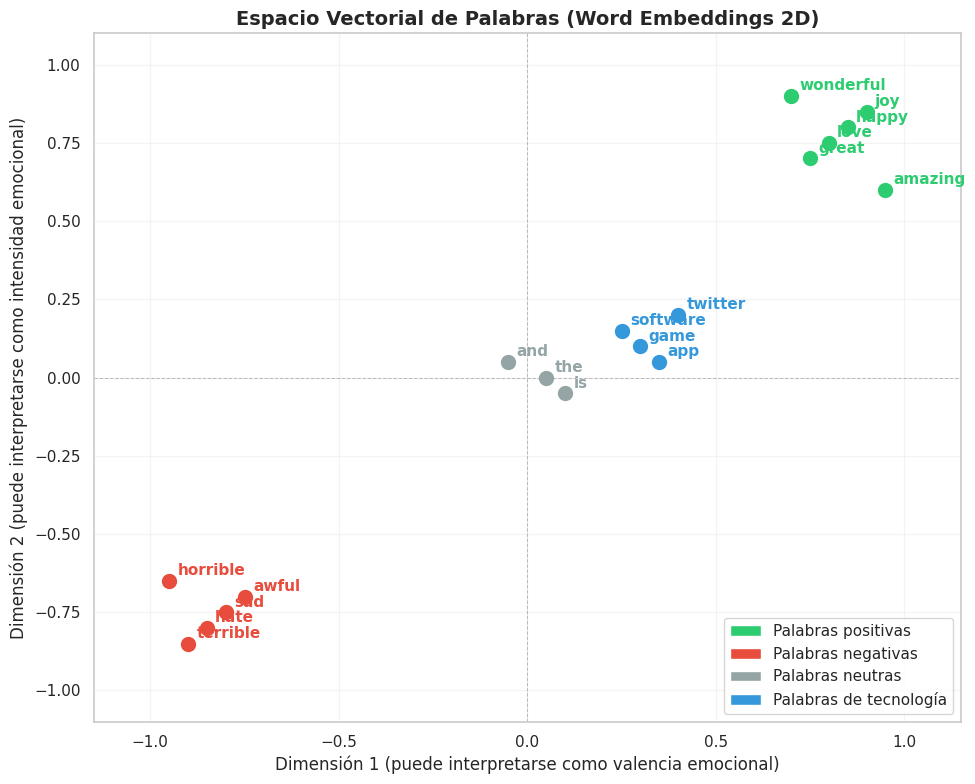


💡 CONCEPTO CLAVE:
   Las palabras con significados similares quedan CERCANAS en el espacio.
   Palabras de sentimiento opuesto quedan en LADOS OPUESTOS.
   Esto permite a la red neuronal hacer ÁLGEBRA con el significado.


In [14]:
# ─── Visualización conceptual de embeddings en 2D ───────────────────────────
# Simulamos embeddings con coordenadas conceptualmente correctas
# (en un proyecto real, vendrían de Word2Vec o GloVe)

words_emotions = {
    # Emociones positivas
    'happy':    (0.85,  0.80),
    'joy':      (0.90,  0.85),
    'love':     (0.80,  0.75),
    'great':    (0.75,  0.70),
    'amazing':  (0.95,  0.60),
    'wonderful':(0.70,  0.90),
    # Emociones negativas
    'sad':      (-0.80, -0.75),
    'hate':     (-0.85, -0.80),
    'terrible': (-0.90, -0.85),
    'awful':    (-0.75, -0.70),
    'horrible': (-0.95, -0.65),
    # Neutras
    'the':      (0.05,  0.00),
    'is':       (0.10, -0.05),
    'and':      (-0.05, 0.05),
    # Tecnología
    'game':     (0.30,  0.10),
    'app':      (0.35,  0.05),
    'software': (0.25,  0.15),
    'twitter':  (0.40,  0.20),
}

color_map = {
    'happy':'#2ecc71','joy':'#2ecc71','love':'#2ecc71','great':'#2ecc71',
    'amazing':'#2ecc71','wonderful':'#2ecc71',
    'sad':'#e74c3c','hate':'#e74c3c','terrible':'#e74c3c','awful':'#e74c3c','horrible':'#e74c3c',
    'the':'#95a5a6','is':'#95a5a6','and':'#95a5a6',
    'game':'#3498db','app':'#3498db','software':'#3498db','twitter':'#3498db'
}

fig, ax = plt.subplots(figsize=(10, 8))

for word, (x, y) in words_emotions.items():
    ax.scatter(x, y, color=color_map[word], s=100, zorder=5)
    ax.annotate(word, (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=11, fontweight='bold',
                color=color_map[word])

# Eje de referencia
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Palabras positivas'),
    Patch(facecolor='#e74c3c', label='Palabras negativas'),
    Patch(facecolor='#95a5a6', label='Palabras neutras'),
    Patch(facecolor='#3498db', label='Palabras de tecnología'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_title('Espacio Vectorial de Palabras (Word Embeddings 2D)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dimensión 1 (puede interpretarse como valencia emocional)')
ax.set_ylabel('Dimensión 2 (puede interpretarse como intensidad emocional)')
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.10, 1.10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print('\n💡 CONCEPTO CLAVE:')
print('   Las palabras con significados similares quedan CERCANAS en el espacio.')
print('   Palabras de sentimiento opuesto quedan en LADOS OPUESTOS.')
print('   Esto permite a la red neuronal hacer ÁLGEBRA con el significado.')

---
## 🧹 Sección 5 — Preprocesamiento de Texto

El lenguaje de Twitter es especialmente ruidoso: abreviaciones, emojis, hashtags, menciones, errores ortográficos. Debemos limpiar el texto antes de pasarlo al modelo.

### Pasos de preprocesamiento para Twitter:

1. Eliminar menciones (`@usuario`)
2. Eliminar URLs (`http://...`)
3. Eliminar hashtags (o solo el `#`)
4. Expandir contracciones (`I'm` → `I am`)
5. Eliminar caracteres especiales y números
6. Convertir a minúsculas
7. Tokenizar
8. Eliminar stopwords
9. Lemmatizar


In [15]:
# ─── Función de limpieza de texto ───────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_tweet(text: str) -> str:
    """Pipeline completo de limpieza para tweets."""
    if not isinstance(text, str):
        return ''

    # 1. Minúsculas
    text = text.lower()

    # 2. Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 3. Eliminar menciones (@usuario)
    text = re.sub(r'@\w+', '', text)

    # 4. Eliminar hashtags (mantenemos la palabra, quitamos #)
    text = re.sub(r'#(\w+)', r'\1', text)

    # 5. Expandir contracciones  (I'm → I am, don't → do not)
    try:
        text = contractions.fix(text)
    except Exception:
        pass

    # 6. Eliminar caracteres especiales y números
    text = re.sub(r'[^a-z\s]', '', text)

    # 7. Tokenizar
    tokens = text.split()

    # 8. Eliminar stopwords y tokens muy cortos
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 9. Lemmatización
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# ─── Demostración del pipeline ───────────────────────────────────────────────
demo_tweets = [
    "@Microsoft I'm absolutely LOVING the new update! #Windows11 is amazing 🔥",
    "This game is terrible... worst $60 I've ever spent. Don't buy it! http://review.com",
    "Just updated my drivers. Works fine now.",
]

print('DEMOSTRACIÓN DEL PIPELINE DE LIMPIEZA')
print('='*60)
for tweet in demo_tweets:
    cleaned = clean_tweet(tweet)
    print(f'\n  ANTES : {tweet}')
    print(f'  DESPUÉS: {cleaned}')

DEMOSTRACIÓN DEL PIPELINE DE LIMPIEZA

  ANTES : @Microsoft I'm absolutely LOVING the new update! #Windows11 is amazing 🔥
  DESPUÉS: absolutely loving new update window amazing

  ANTES : This game is terrible... worst $60 I've ever spent. Don't buy it! http://review.com
  DESPUÉS: game terrible worst ever spent buy

  ANTES : Just updated my drivers. Works fine now.
  DESPUÉS: updated driver work fine


In [16]:
# ─── Aplicar limpieza al dataset completo ───────────────────────────────────
print('Limpiando tweets... (puede tardar 1-2 minutos)')

train_df['clean_text'] = train_df['text'].apply(clean_tweet)
val_df['clean_text']   = val_df['text'].apply(clean_tweet)

# Eliminar filas con texto vacío después de limpieza
train_df = train_df[train_df['clean_text'].str.strip() != ''].reset_index(drop=True)
val_df   = val_df[val_df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Dataset limpio: {len(train_df):,} tweets en entrenamiento')
print(f'   Dataset limpio: {len(val_df):,} tweets en validación')

# Verificación
train_df[['text', 'clean_text', 'sentiment']].head(5)

Limpiando tweets... (puede tardar 1-2 minutos)
✅ Dataset limpio: 72,171 tweets en entrenamiento
   Dataset limpio: 999 tweets en validación


,text,clean_text,sentiment
0,im getting on borderlands and i will murder yo...,getting borderland murder,Positive
1,I am coming to the borders and I will kill you...,coming border kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderland kill,Positive
3,im coming on borderlands and i will murder you...,coming borderland murder,Positive
4,im getting on borderlands 2 and i will murder ...,getting borderland murder,Positive


/tmp/ipykernel_10374/1748168692.py:30: UserWarning: Glyph 128277 (\N{BELL WITH CANCELLATION STROKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128277 (\N{BELL WITH CANCELLATION STROKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


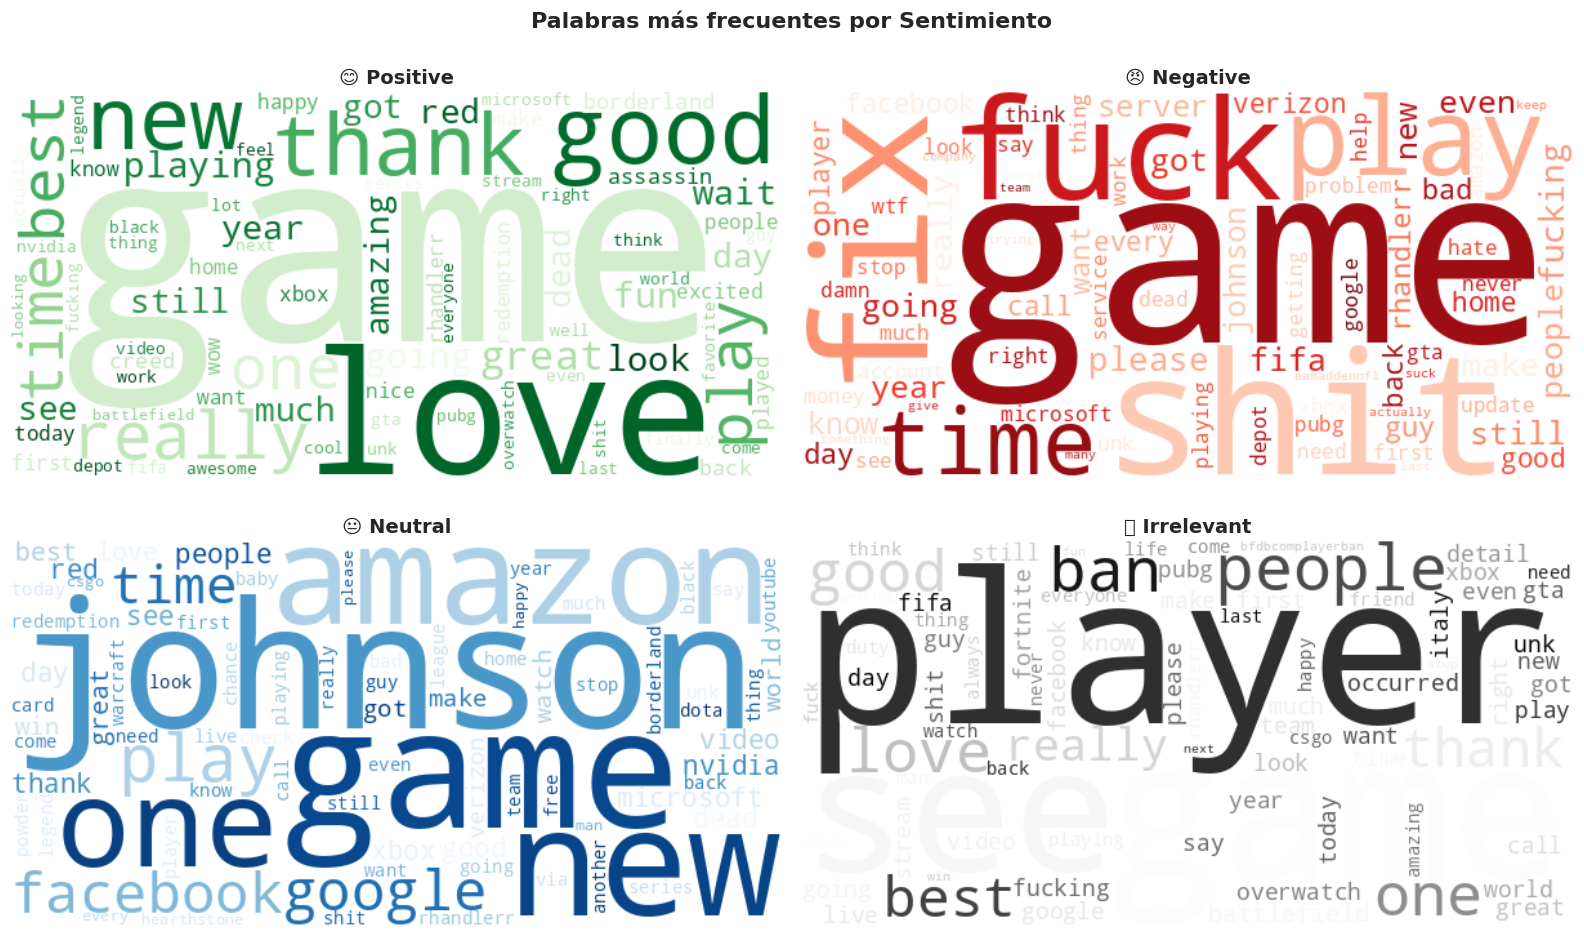

In [17]:
# ─── Nubes de palabras por sentimiento ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

color_wc = {
    'Positive':   'Greens',
    'Negative':   'Reds',
    'Neutral':    'Blues',
    'Irrelevant': 'Greys'
}

for idx, sentiment in enumerate(['Positive', 'Negative', 'Neutral', 'Irrelevant']):
    text_combined = ' '.join(
        train_df[train_df['sentiment'] == sentiment]['clean_text'].tolist()
    )
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=color_wc[sentiment],
        max_words=80,
        collocations=False
    ).generate(text_combined)

    icon = {'Positive':'😊','Negative':'😠','Neutral':'😐','Irrelevant':'🔕'}[sentiment]
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{icon} {sentiment}', fontsize=14, fontweight='bold')

plt.suptitle('Palabras más frecuentes por Sentimiento', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ─── Preparación para modelos: Codificación de etiquetas ─────────────────────
# Para los modelos clásicos usaremos SVM y Random Forest sobre TF-IDF
# Para Deep Learning usaremos embeddings aprendidos automáticamente

# Codificar sentimientos como números
label_encoder = LabelEncoder()
label_encoder.fit(train_df['sentiment'])

y_train_enc = label_encoder.transform(train_df['sentiment'])
y_val_enc   = label_encoder.transform(val_df['sentiment'])

label_map = {i: l for i, l in enumerate(label_encoder.classes_)}
print('Mapa de etiquetas:')
print(label_map)

NUM_CLASSES = len(label_encoder.classes_)
print(f'\nNúmero de clases: {NUM_CLASSES}')

Mapa de etiquetas:
{0: 'Irrelevant', 1: 'Negative', 2: 'Neutral', 3: 'Positive'}

Número de clases: 4


---
## 🤖 Sección 6 — Modelos Clásicos de Machine Learning

Antes del Deep Learning, el análisis de sentimientos se hacía con modelos clásicos combinados con representaciones vectoriales de texto.

### TF-IDF (Term Frequency – Inverse Document Frequency)

**TF** mide cuánto aparece una palabra en un documento.  
**IDF** penaliza palabras que aparecen en muchos documentos (como "the" o "is").  
El resultado: palabras raras y específicas tienen más peso.

### Support Vector Machine (SVM)

SVM busca un **hiperplano** que separe las clases con el margen más grande posible. Es muy efectivo en problemas de texto de alta dimensión.

### Random Forest

Construye **muchos árboles de decisión** y combina sus votos. Más robusto que un solo árbol.


In [19]:
# ─── Vectorización TF-IDF ────────────────────────────────────────────────────
print('Construyendo representaciones TF-IDF...')

tfidf = TfidfVectorizer(
    max_features=30000,    # vocabulario máximo
    ngram_range=(1, 2),    # unigramas + bigramas
    min_df=2,              # ignorar palabras que aparecen menos de 2 veces
    sublinear_tf=True      # aplica log(TF) para suavizar frecuencias altas
)

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf   = tfidf.transform(val_df['clean_text'])

print(f'✅ Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}')
print(f'   Cada tweet es un vector de {X_train_tfidf.shape[1]:,} dimensiones')
print(f'   (una por cada palabra en el vocabulario)')

Construyendo representaciones TF-IDF...
✅ Matriz TF-IDF de entrenamiento: (72171, 30000)
   Cada tweet es un vector de 30,000 dimensiones
   (una por cada palabra en el vocabulario)


In [20]:
# ─── Función de evaluación estándar ─────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, classes):
    """Imprime métricas y dibuja matriz de confusión."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')

    print(f'\n{"="*55}')
    print(f'  RESULTADOS: {model_name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=classes))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión — {model_name}', fontweight='bold')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.tight_layout()
    plt.show()

    return acc, f1


# Almacenaremos resultados de todos los modelos aquí
results = {}

Entrenando SVM...

  RESULTADOS: Support Vector Machine (TF-IDF)
  Accuracy  : 0.9540 (95.40%)
  F1-Score  : 0.9540

              precision    recall  f1-score   support

  Irrelevant       0.95      0.94      0.94       172
    Negative       0.95      0.97      0.96       265
     Neutral       0.97      0.94      0.96       285
    Positive       0.94      0.96      0.95       277

    accuracy                           0.95       999
   macro avg       0.95      0.95      0.95       999
weighted avg       0.95      0.95      0.95       999



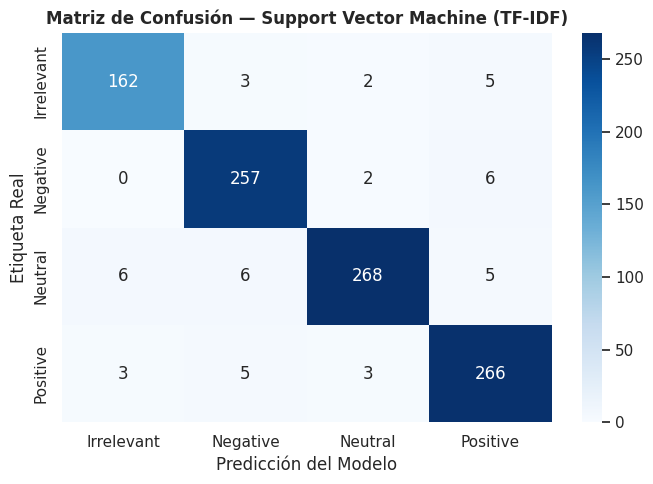

In [21]:
# ─── Modelo 1: Support Vector Machine ───────────────────────────────────────
print('Entrenando SVM...')
svm_model = LinearSVC(max_iter=2000, C=1.0, random_state=SEED)
svm_model.fit(X_train_tfidf, y_train_enc)

y_pred_svm = svm_model.predict(X_val_tfidf)

acc_svm, f1_svm = evaluate_model(
    'Support Vector Machine (TF-IDF)',
    y_val_enc, y_pred_svm,
    label_encoder.classes_
)
results['SVM'] = {'accuracy': acc_svm, 'f1': f1_svm}

Entrenando Random Forest (puede tardar ~1 minuto)...

  RESULTADOS: Random Forest (TF-IDF)
  Accuracy  : 0.5065 (50.65%)
  F1-Score  : 0.4465

              precision    recall  f1-score   support

  Irrelevant       1.00      0.03      0.06       172
    Negative       0.40      0.97      0.56       265
     Neutral       0.93      0.25      0.39       285
    Positive       0.65      0.63      0.64       277

    accuracy                           0.51       999
   macro avg       0.74      0.47      0.41       999
weighted avg       0.72      0.51      0.45       999



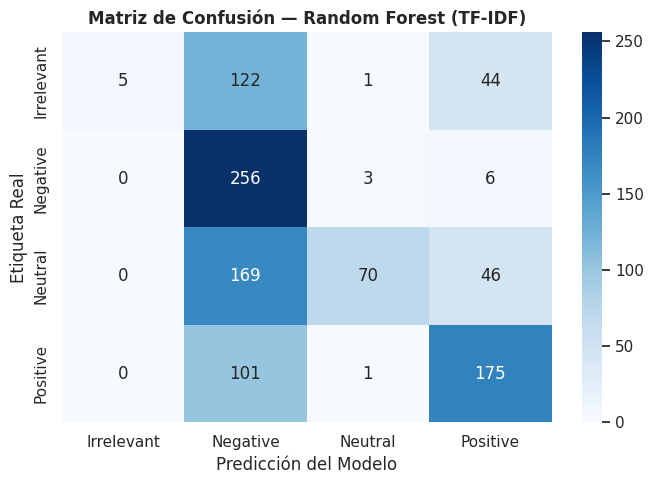

In [22]:
# ─── Modelo 2: Random Forest ─────────────────────────────────────────────────
print('Entrenando Random Forest (puede tardar ~1 minuto)...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_train_tfidf, y_train_enc)

y_pred_rf = rf_model.predict(X_val_tfidf)

acc_rf, f1_rf = evaluate_model(
    'Random Forest (TF-IDF)',
    y_val_enc, y_pred_rf,
    label_encoder.classes_
)
results['Random Forest'] = {'accuracy': acc_rf, 'f1': f1_rf}

Entrenando Árbol de Decisión...

  RESULTADOS: Árbol de Decisión (TF-IDF)
  Accuracy  : 0.5235 (52.35%)
  F1-Score  : 0.5062

              precision    recall  f1-score   support

  Irrelevant       0.97      0.20      0.33       172
    Negative       0.39      0.94      0.55       265
     Neutral       0.78      0.35      0.49       285
    Positive       0.73      0.51      0.60       277

    accuracy                           0.52       999
   macro avg       0.72      0.50      0.49       999
weighted avg       0.70      0.52      0.51       999



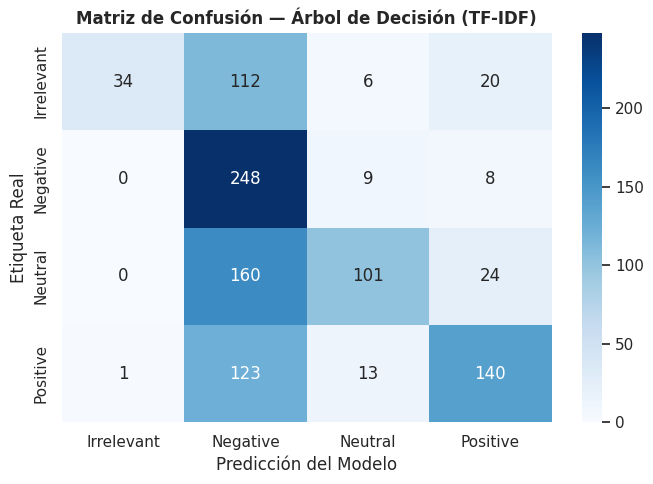

In [23]:
# ─── Modelo 3: Árbol de Decisión ─────────────────────────────────────────────
print('Entrenando Árbol de Decisión...')
dt_model = DecisionTreeClassifier(max_depth=30, random_state=SEED)
dt_model.fit(X_train_tfidf, y_train_enc)

y_pred_dt = dt_model.predict(X_val_tfidf)

acc_dt, f1_dt = evaluate_model(
    'Árbol de Decisión (TF-IDF)',
    y_val_enc, y_pred_dt,
    label_encoder.classes_
)
results['Árbol de Decisión'] = {'accuracy': acc_dt, 'f1': f1_dt}

---
## 🔁 Sección 7 — Redes Neuronales Recurrentes (LSTM / GRU)

### ¿Por qué necesitamos redes recurrentes para texto?

Los modelos clásicos como SVM ven un tweet como una **bolsa de palabras**: no importa el orden. Pero en lenguaje natural, el orden importa mucho:

```
"El perro mordió al hombre"  ≠  "El hombre mordió al perro"
```

### ¿Cómo funciona una RNN?

Una RNN **lee el texto palabra por palabra**, manteniendo un **estado interno** (memoria) que se actualiza a medida que lee:

```
h₀ → ["I"] → h₁ → ["love"] → h₂ → ["this"] → h₃ → ["game"] → h₄ → Predicción
```

El estado `h₄` contiene un resumen de toda la secuencia.

### El problema del gradiente desvaneciente y la solución: LSTM

Las RNN simples olvidan lo que leyeron hace mucho. **LSTM (Long Short-Term Memory)** soluciona esto con **puertas** que controlan qué recordar y qué olvidar:

- **Forget gate**: decide qué olvidar del estado anterior
- **Input gate**: decide qué nueva información almacenar
- **Output gate**: decide qué parte del estado pasar hacia adelante

**GRU (Gated Recurrent Unit)** es una versión simplificada de LSTM, más rápida y generalmente igual de efectiva.


In [26]:
# ─── Preparación de secuencias para Deep Learning ────────────────────────────
VOCAB_SIZE  = 30000   # tamaño del vocabulario
MAX_LEN     = 60      # longitud máxima de la secuencia
EMBED_DIM   = 64      # dimensión de los embeddings aprendidos

# Tokenizador: asigna un número entero a cada palabra
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>'   # token especial para palabras desconocidas
)
tokenizer.fit_on_texts(train_df['clean_text'])

# Convertir texto a secuencias de enteros
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['clean_text'])

# Padding: todos los tweets deben tener la misma longitud
# tweets cortos → se rellenan con ceros al inicio
# tweets largos → se truncan al inicio
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='pre', truncating='pre')

# Etiquetas en formato one-hot (necesario para categorical_crossentropy)
y_train_cat = to_categorical(y_train_enc, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val_enc,   num_classes=NUM_CLASSES)

print('✅ Secuencias preparadas:')
print(f'   X_train_pad shape: {X_train_pad.shape}')
print(f'   X_val_pad shape  : {X_val_pad.shape}')
print()
print('Ejemplo de transformación:')
sample_text = train_df['clean_text'].iloc[0]
sample_seq  = X_train_seq[0]
sample_pad  = X_train_pad[0]
print(f'  Texto   : "{sample_text}"')
print(f'  Secuencia: {sample_seq[:10]}...')
print(f'  Con padding (60 tokens): {sample_pad[:15]}...')

✅ Secuencias preparadas:
   X_train_pad shape: (72171, 60)
   X_val_pad shape  : (999, 60)

Ejemplo de transformación:
  Texto   : "getting borderland murder"
  Secuencia: [82, 70, 1281]...
  Con padding (60 tokens): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...


In [27]:
# ─── Modelo LSTM ─────────────────────────────────────────────────────────────

def build_lstm_model(vocab_size, embed_dim, max_len, num_classes):
    """Construye un modelo LSTM para clasificación de sentimientos."""
    model = Sequential([
        # Capa de Embedding: convierte índices de palabras en vectores densos
        # input_length eliminado (deprecado en Keras 3)
        Embedding(vocab_size, embed_dim, name='embedding'),

        # LSTM Bidireccional: lee la secuencia en ambas direcciones
        Bidirectional(LSTM(64, return_sequences=True), name='bidirectional_lstm'),

        # Segunda capa LSTM
        LSTM(32, name='lstm_2'),

        # Regularización — nombres únicos para cada Dropout
        Dropout(0.4, name='dropout_1'),

        # Capa densa intermedia
        Dense(32, activation='relu', name='dense_hidden'),
        Dropout(0.3, name='dropout_2'),

        # Capa de salida
        Dense(num_classes, activation='softmax', name='output')
    ])
    return model


lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ─── Entrenamiento del modelo LSTM ───────────────────────────────────────────

# Callbacks para detener el entrenamiento si no mejora
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

print('Entrenando modelo LSTM... (puede tardar 5-10 minutos en CPU)')
print('Recomendado: activar GPU en Colab → Entorno de ejecución → Cambiar tipo de entorno')

history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Entrenando modelo LSTM... (puede tardar 5-10 minutos en CPU)
Recomendado: activar GPU en Colab → Entorno de ejecución → Cambiar tipo de entorno
Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 162s 252ms/step - accuracy: 0.6053 - loss: 0.9781 - val_accuracy: 0.8478 - val_loss: 0.4441 - learning_rate: 0.0010
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 147s 261ms/step - accuracy: 0.8448 - loss: 0.4671 - val_accuracy: 0.9029 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 139s 246ms/step - accuracy: 0.8998 - loss: 0.3074 - val_accuracy: 0.9079 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 138s 245ms/step - accuracy: 0.9179 - loss: 0.2512 - val_accuracy: 0.9179 - val_loss: 0.3143 - learning_rate: 0.0010
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9236 - loss: 0.2268
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
564/564 ━━━━━━━━━━━━━━━━━━━━ 138s 244ms/step - accuracy: 0.9275 - lo

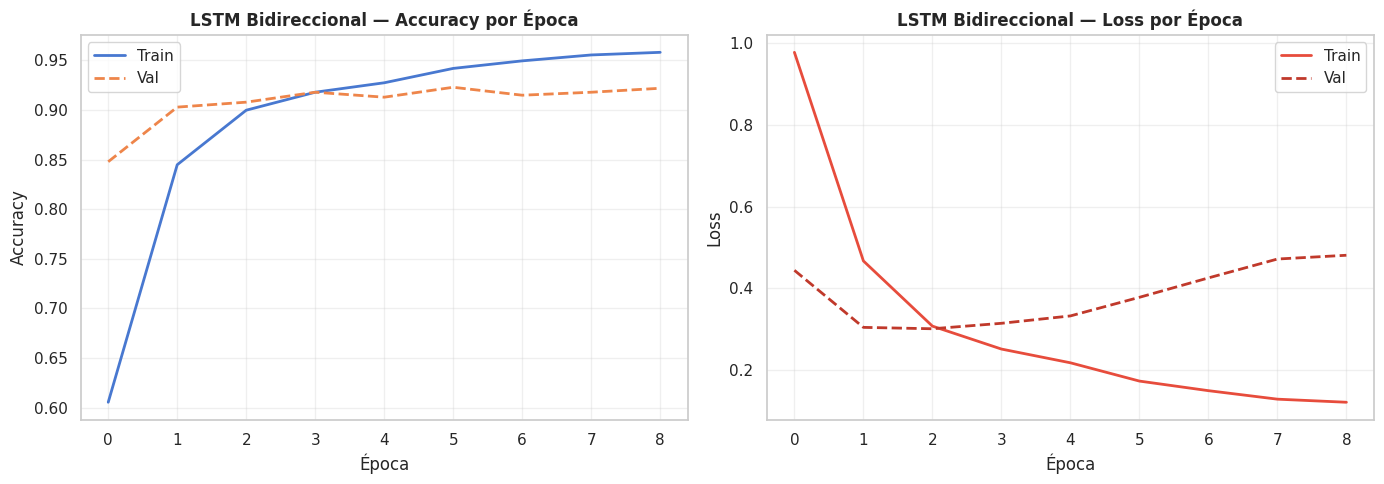

💡 Si Train >> Val: hay overfitting (el modelo memorizó, no aprendió)
   Si ambas curvas convergen: buen aprendizaje generalizado

  RESULTADOS: LSTM Bidireccional
  Accuracy  : 0.9229 (92.29%)
  F1-Score  : 0.9230

              precision    recall  f1-score   support

  Irrelevant       0.88      0.94      0.90       172
    Negative       0.93      0.95      0.94       265
     Neutral       0.95      0.89      0.92       285
    Positive       0.92      0.93      0.92       277

    accuracy                           0.92       999
   macro avg       0.92      0.92      0.92       999
weighted avg       0.92      0.92      0.92       999



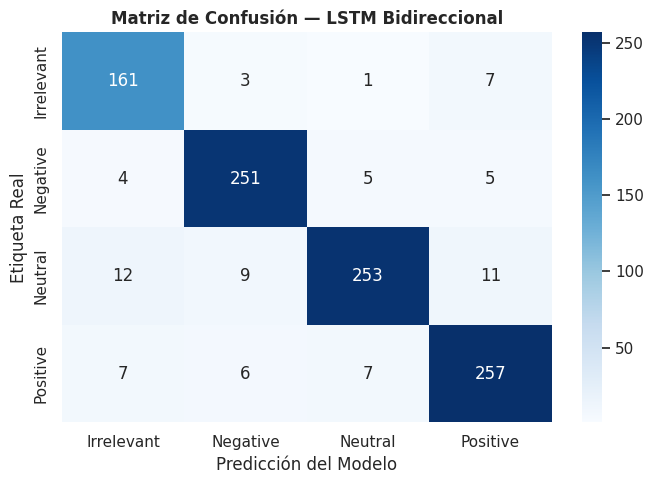

In [29]:
# ─── Evaluación y curvas de entrenamiento LSTM ───────────────────────────────

def plot_training_history(history, model_name):
    """Visualiza la evolución del entrenamiento."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy por Época', fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2, color='#e74c3c')
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--', color='#c0392b')
    axes[1].set_title(f'{model_name} — Loss por Época', fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('💡 Si Train >> Val: hay overfitting (el modelo memorizó, no aprendió)')
    print('   Si ambas curvas convergen: buen aprendizaje generalizado')


plot_training_history(history_lstm, 'LSTM Bidireccional')

# Predicciones
y_pred_lstm_prob = lstm_model.predict(X_val_pad, verbose=0)
y_pred_lstm      = np.argmax(y_pred_lstm_prob, axis=1)

acc_lstm, f1_lstm = evaluate_model(
    'LSTM Bidireccional',
    y_val_enc, y_pred_lstm,
    label_encoder.classes_
)
results['LSTM Bidireccional'] = {'accuracy': acc_lstm, 'f1': f1_lstm}

In [30]:
# ─── Modelo GRU ──────────────────────────────────────────────────────────────
def build_gru_model(vocab_size, embed_dim, max_len, num_classes):
    """GRU: más rápido que LSTM, generalmente resultados similares."""
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Bidirectional(GRU(64, return_sequences=True)),
        GRU(32),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model


gru_model = build_gru_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
gru_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print('Entrenando modelo GRU...')
history_gru = gru_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_gru, 'GRU Bidireccional')

y_pred_gru_prob = gru_model.predict(X_val_pad, verbose=0)
y_pred_gru      = np.argmax(y_pred_gru_prob, axis=1)

acc_gru, f1_gru = evaluate_model(
    'GRU Bidireccional',
    y_val_enc, y_pred_gru,
    label_encoder.classes_
)
results['GRU Bidireccional'] = {'accuracy': acc_gru, 'f1': f1_gru}

Entrenando modelo GRU...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


564/564 ━━━━━━━━━━━━━━━━━━━━ 167s 285ms/step - accuracy: 0.6074 - loss: 0.9664 - val_accuracy: 0.8829 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 199s 280ms/step - accuracy: 0.8527 - loss: 0.4398 - val_accuracy: 0.9139 - val_loss: 0.2935 - learning_rate: 0.0010
Epoch 3/15
399/564 ━━━━━━━━━━━━━━━━━━━━ 46s 284ms/step - accuracy: 0.8926 - loss: 0.3229

KeyboardInterrupt: 

---
## 🧩 Sección 8 — Mecanismos de Atención y Transformers

### El problema con LSTM: la memoria es limitada

Aunque LSTM mejora la memoria de las RNN simples, sigue teniendo dificultades con textos muy largos. La información de las primeras palabras puede diluirse.

### ¿Qué es el mecanismo de atención?

La atención permite al modelo **"mirar hacia atrás"** en toda la secuencia cuando está procesando cada palabra. En lugar de solo usar el estado oculto final, la red puede ponderar qué palabras son más relevantes para la predicción:

```
Tweet: "This game is NOT good at all"

Al predecir sentimiento, el modelo da más peso a:
  "NOT" → peso alto (negación)
  "good" → peso alto (adjetivo de evaluación)
  "is", "at", "all" → peso bajo (palabras de relleno)
```

### Transformers (2017 — "Attention is All You Need")

Los Transformers reemplazaron completamente las RNN con un mecanismo llamado **Self-Attention**. Cada palabra puede relacionarse directamente con cualquier otra palabra en la secuencia sin importar la distancia.

**BERT** (Google, 2018): entrena leyendo texto en ambas direcciones, de izquierda a derecha y de derecha a izquierda simultáneamente.  
**GPT** (OpenAI): entrena prediciendo la siguiente palabra, generando texto.

### Ventaja sobre LSTM:
- Capturan dependencias de largo alcance mejor
- Se pueden paralelizar (entrenan mucho más rápido)
- Producen embeddings contextuales (misma palabra, distintos vectores según contexto)


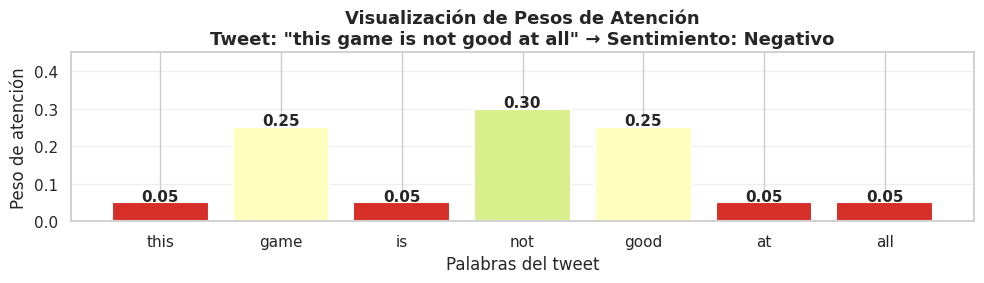


💡 INTERPRETACIÓN:
   El modelo aprende a prestar más ATENCIÓN a "not" y "good"
   porque son las palabras que determinan el sentimiento negativo.
   Palabras como "is", "at", "all" reciben muy poco peso.


In [31]:
# ─── Visualización conceptual: Mecanismo de Atención ────────────────────────
# Simulamos los pesos de atención para un tweet de ejemplo

tweet_example = ["this", "game", "is", "not", "good", "at", "all"]

# Pesos de atención simulados (en un modelo real, estos los aprende la red)
attention_weights = np.array([0.05, 0.25, 0.05, 0.30, 0.25, 0.05, 0.05])

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.bar(tweet_example, attention_weights,
              color=[plt.cm.RdYlGn(w * 2) for w in attention_weights],
              edgecolor='white', linewidth=1.5)

for bar, weight in zip(bars, attention_weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{weight:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Visualización de Pesos de Atención\n'
             'Tweet: "this game is not good at all" → Sentimiento: Negativo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Palabras del tweet')
ax.set_ylabel('Peso de atención')
ax.set_ylim(0, 0.45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('   El modelo aprende a prestar más ATENCIÓN a "not" y "good"')
print('   porque son las palabras que determinan el sentimiento negativo.')
print('   Palabras como "is", "at", "all" reciben muy poco peso.')

In [32]:
# ─── Comparación conceptual de arquitecturas NLP ─────────────────────────────

architectures = {
    'BoW + SVM': {
        'ventajas': 'Rápido, interpretable, funciona bien con poco dato',
        'desventajas': 'No captura orden ni contexto',
        'año': 2000
    },
    'Word2Vec + RNN': {
        'ventajas': 'Captura orden y significado semántico',
        'desventajas': 'Olvida contexto lejano, lento de entrenar',
        'año': 2013
    },
    'LSTM/GRU': {
        'ventajas': 'Buena memoria de largo plazo, buen rendimiento',
        'desventajas': 'Secuencial, no paralelizable, lento',
        'año': 2014
    },
    'Transformer': {
        'ventajas': 'Atención global, paralelizable, estado del arte',
        'desventajas': 'Requiere muchos datos, costoso computacionalmente',
        'año': 2017
    },
    'BERT / GPT': {
        'ventajas': 'Pre-entrenado en miles de millones de textos, embeddings contextuales',
        'desventajas': 'Muy pesado, difícil de interpretar',
        'año': 2018
    }
}

print('EVOLUCIÓN DE LAS ARQUITECTURAS DE NLP')
print('='*65)
for arch, info in architectures.items():
    print(f'\n📌 {arch} ({info["año"]})')
    print(f'   ✅ {info["ventajas"]}')
    print(f'   ⚠️  {info["desventajas"]}')

EVOLUCIÓN DE LAS ARQUITECTURAS DE NLP

📌 BoW + SVM (2000)
   ✅ Rápido, interpretable, funciona bien con poco dato
   ⚠️  No captura orden ni contexto

📌 Word2Vec + RNN (2013)
   ✅ Captura orden y significado semántico
   ⚠️  Olvida contexto lejano, lento de entrenar

📌 LSTM/GRU (2014)
   ✅ Buena memoria de largo plazo, buen rendimiento
   ⚠️  Secuencial, no paralelizable, lento

📌 Transformer (2017)
   ✅ Atención global, paralelizable, estado del arte
   ⚠️  Requiere muchos datos, costoso computacionalmente

📌 BERT / GPT (2018)
   ✅ Pre-entrenado en miles de millones de textos, embeddings contextuales
   ⚠️  Muy pesado, difícil de interpretar


---
## 📊 Sección 9 — Evaluación y Métricas

### ¿Qué mide cada métrica?

| Métrica | Definición | En análisis de sentimientos significa... |
|---------|------------|------------------------------------------|
| **Accuracy** | % de predicciones correctas | De todos los tweets clasificados, ¿cuántos clasifiqué bien? |
| **Precision** | De los que predije como X, ¿cuántos eran realmente X? | Si digo "Positivo", ¿qué tan confiable soy? |
| **Recall** | De todos los X reales, ¿cuántos detecté? | ¿Estoy perdiendo tweets negativos? |
| **F1-Score** | Media armónica de Precision y Recall | Métrica equilibrada cuando las clases son desiguales |

### La Matriz de Confusión

Una tabla que muestra **qué predijo el modelo vs qué era real**:

```
                 PREDICHO
              Pos  Neg  Neu  Irr
REAL  Pos   [ ✓   ✗    ✗    ✗ ]   ← ¿Cuántos positivos detecté bien?
      Neg   [ ✗   ✓    ✗    ✗ ]   ← ¿Confundo negativos con neutros?
      Neu   [ ✗   ✗    ✓    ✗ ]
      Irr   [ ✗   ✗    ✗    ✓ ]
```


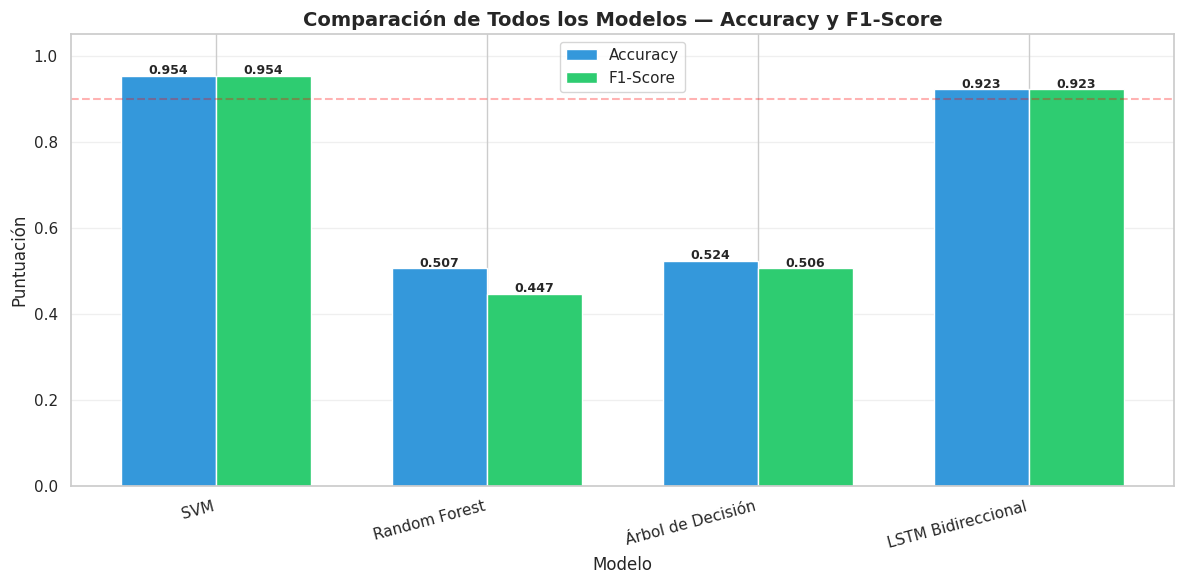


🏆 RANKING DE MODELOS:
  1. SVM                            Accuracy=0.9540  F1=0.9540
  2. LSTM Bidireccional             Accuracy=0.9229  F1=0.9230
  3. Árbol de Decisión              Accuracy=0.5235  F1=0.5062
  4. Random Forest                  Accuracy=0.5065  F1=0.4465


In [33]:
# ─── Comparación final de todos los modelos ──────────────────────────────────
models_names = list(results.keys())
accuracies   = [results[m]['accuracy'] for m in models_names]
f1_scores    = [results[m]['f1']       for m in models_names]

x = np.arange(len(models_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width,
               label='Accuracy', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_scores,  width,
               label='F1-Score', color='#2ecc71', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Modelo')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Todos los Modelos — Accuracy y F1-Score',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.3, label='Objetivo 90%')
plt.tight_layout()
plt.show()

print('\n🏆 RANKING DE MODELOS:')
ranking = sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True)
for i, (name, metrics) in enumerate(ranking, 1):
    print(f'  {i}. {name:30} Accuracy={metrics["accuracy"]:.4f}  F1={metrics["f1"]:.4f}')

---
## 🌀 Sección 10 — Visualizaciones Avanzadas


Extrayendo embeddings aprendidos...
  Reduciendo dimensión de 64D a 2D con t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


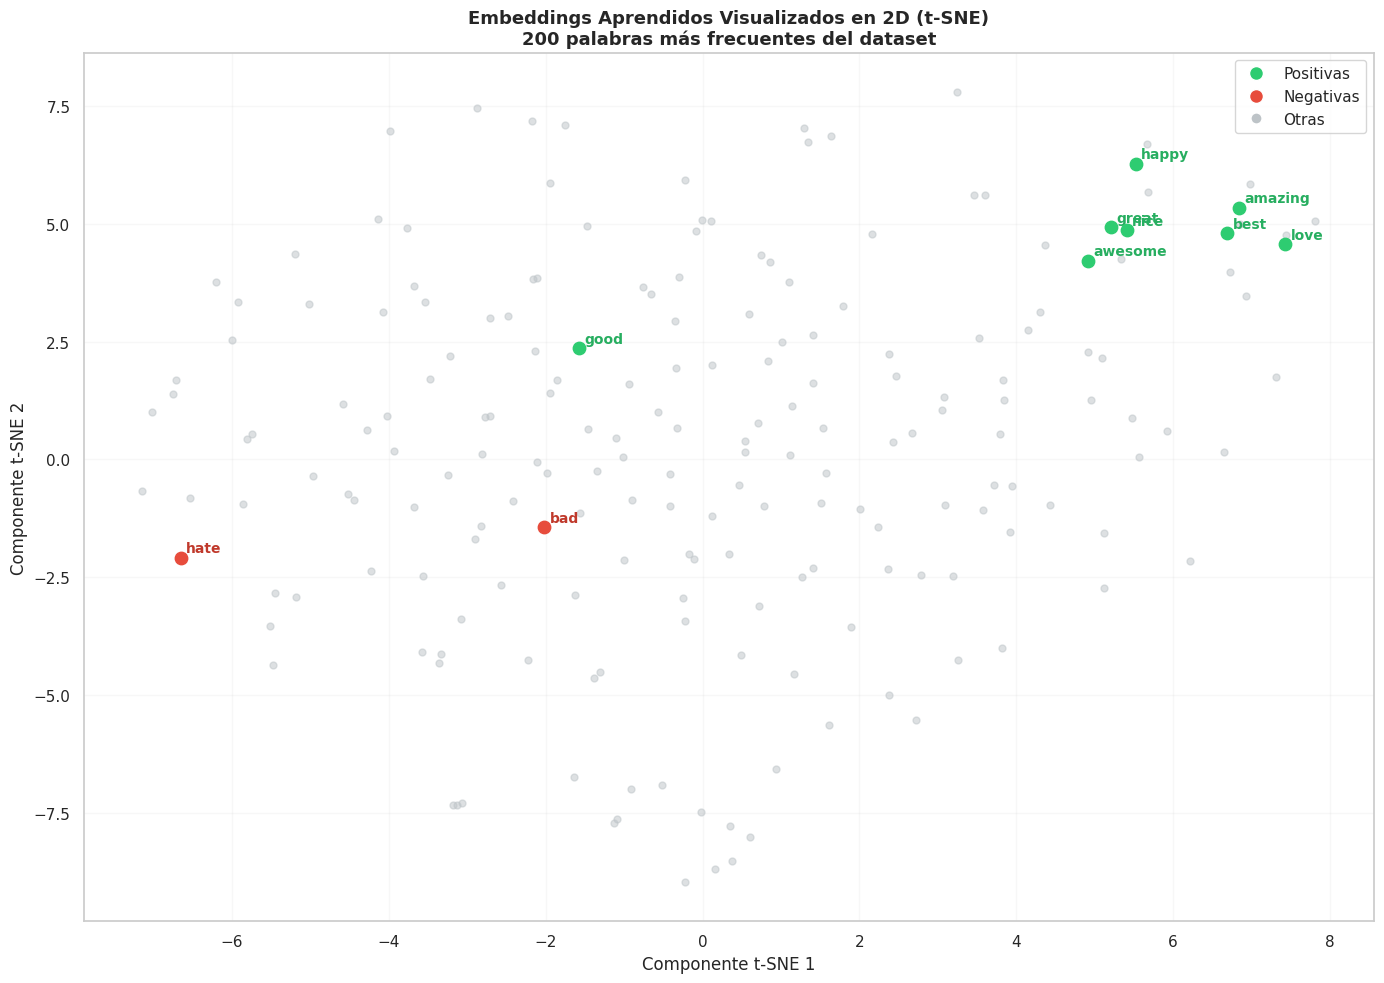


💡 Si el modelo aprendió bien, las palabras positivas (verde)
   y negativas (rojo) deberían estar agrupadas en zonas distintas.


In [34]:
# ─── Visualización de Embeddings aprendidos en 2D (t-SNE) ───────────────────
# Extraemos los pesos de la capa de embedding del modelo LSTM entrenado

print('Extrayendo embeddings aprendidos...')

embedding_layer  = lstm_model.get_layer('embedding')
embedding_matrix = embedding_layer.get_weights()[0]  # shape: (vocab, embed_dim)

# Tomamos las 200 palabras más frecuentes del vocabulario
word_index = tokenizer.word_index
top_words  = sorted(word_index.items(), key=lambda x: x[1])[:200]

vocab_words   = [w for w, i in top_words if i < len(embedding_matrix)]
vocab_vectors = np.array([embedding_matrix[i] for w, i in top_words if i < len(embedding_matrix)])

print(f'  Reduciendo dimensión de {vocab_vectors.shape[1]}D a 2D con t-SNE...')

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
vectors_2d = tsne.fit_transform(vocab_vectors)

# Palabras de ejemplo a destacar
highlight_positive = {'good','great','love','amazing','happy','best','awesome','nice'}
highlight_negative = {'bad','hate','terrible','worst','awful','horrible','poor','broken'}

fig, ax = plt.subplots(figsize=(14, 10))

for i, word in enumerate(vocab_words):
    x_coord, y_coord = vectors_2d[i]
    if word in highlight_positive:
        ax.scatter(x_coord, y_coord, color='#2ecc71', s=80, zorder=5)
        ax.annotate(word, (x_coord, y_coord), fontsize=10,
                    fontweight='bold', color='#27ae60',
                    xytext=(4, 4), textcoords='offset points')
    elif word in highlight_negative:
        ax.scatter(x_coord, y_coord, color='#e74c3c', s=80, zorder=5)
        ax.annotate(word, (x_coord, y_coord), fontsize=10,
                    fontweight='bold', color='#c0392b',
                    xytext=(4, 4), textcoords='offset points')
    else:
        ax.scatter(x_coord, y_coord, color='#bdc3c7', s=25, alpha=0.5)

# Leyenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Positivas'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Negativas'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#bdc3c7', markersize=8,  label='Otras'),
]
ax.legend(handles=legend_elements)

ax.set_title('Embeddings Aprendidos Visualizados en 2D (t-SNE)\n'
             '200 palabras más frecuentes del dataset',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente t-SNE 1')
ax.set_ylabel('Componente t-SNE 2')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print('\n💡 Si el modelo aprendió bien, las palabras positivas (verde)')
print('   y negativas (rojo) deberían estar agrupadas en zonas distintas.')

In [35]:
# ─── Análisis de errores: qué confunde el mejor modelo ──────────────────────
# Usaremos el modelo con mejor F1 de los Deep Learning

best_preds = y_pred_lstm  # cambiar a y_pred_gru si GRU fue mejor

# DataFrame de predicciones vs realidad
results_df = val_df[['text', 'sentiment', 'clean_text']].copy()
results_df['predicted'] = label_encoder.inverse_transform(best_preds)
results_df['correct']   = results_df['sentiment'] == results_df['predicted']

# Análisis de errores
errors_df = results_df[~results_df['correct']]

print(f'Total de errores: {len(errors_df)} / {len(results_df)} tweets')
print(f'Tasa de error: {len(errors_df)/len(results_df)*100:.1f}%\n')

# Análisis de confusión por pares
confusion_pairs = errors_df.groupby(['sentiment', 'predicted']).size().reset_index(name='count')
confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(10)
print('PARES DE CONFUSIÓN MÁS FRECUENTES:')
print(confusion_pairs.to_string(index=False))

print('\n📌 EJEMPLOS DE TWEETS MAL CLASIFICADOS:')
for _, row in errors_df.head(6).iterrows():
    print(f'\n  Real: {row["sentiment"]:12} → Predicho: {row["predicted"]}')
    print(f'  Tweet: {str(row["text"])[:100]}')

Total de errores: 77 / 999 tweets
Tasa de error: 7.7%

PARES DE CONFUSIÓN MÁS FRECUENTES:
 sentiment  predicted  count
   Neutral Irrelevant     12
   Neutral   Positive     11
   Neutral   Negative      9
Irrelevant   Positive      7
  Positive    Neutral      7
  Positive Irrelevant      7
  Positive   Negative      6
  Negative    Neutral      5
  Negative   Positive      5
  Negative Irrelevant      4

📌 EJEMPLOS DE TWEETS MAL CLASIFICADOS:

  Real: Positive     → Predicho: Irrelevant
  Tweet: Rocket League, Sea of Thieves or Rainbow Six: Siege🤔? I love playing all three on stream but which i

  Real: Negative     → Predicho: Positive
  Tweet: The new @CallofDuty for ps5 is 🔥🔥🔥🔥
Oh God 😭😍

  Real: Irrelevant   → Predicho: Positive
  Tweet: Call of duty warzone (livestream) w/ subs #Warzone youtu.be/7BhH_pjOMU4 via @YouTube Please come wat

  Real: Negative     → Predicho: Neutral
  Tweet: Yo! @Verizon just added a $120 'fee' to my account under #COVID19 protection without my permis

---
## ⚠️ Sección 11 — Limitaciones del NLP: Sarcasmo, Ironía y Ambigüedad

### Los problemas más difíciles para las máquinas

#### 1. Sarcasmo e Ironía
```
"Oh, BRILLIANT idea making the game crash every hour 🙄"
```
Las palabras son "positivas" (brilliant) pero el sentimiento es claramente negativo.

#### 2. Negación
```
"This game is NOT good" → Negativo
"This game is NOT bad"  → Positivo
```
El modelo debe aprender que "not" invierte el sentimiento de lo que sigue.

#### 3. Doble sentido
```
"I'm sick" → puede ser enfermedad O slang para "esto está genial"
```

#### 4. Contexto cultural
```
"That's fire" → Muy bueno (slang)
"That's lit"  → Excelente (slang)
```

#### 5. Emojis y ambigüedad visual
```
"This update 💀" → ¿muerte = malo? ¿o slang para "morí de risa"?
```


In [36]:
# ─── Prueba de casos difíciles ───────────────────────────────────────────────

def predict_sentiment(texts, model, tokenizer, label_encoder, max_len):
    """Predice el sentimiento de una lista de textos."""
    cleaned  = [clean_tweet(t) for t in texts]
    seqs     = tokenizer.texts_to_sequences(cleaned)
    padded   = pad_sequences(seqs, maxlen=max_len, padding='pre', truncating='pre')
    probs    = model.predict(padded, verbose=0)
    preds    = np.argmax(probs, axis=1)
    labels   = label_encoder.inverse_transform(preds)
    confs    = np.max(probs, axis=1)
    return list(zip(texts, labels, confs))


hard_cases = [
    # Sarcasmo
    "Oh brilliant, the game crashes AGAIN. Truly the best software I've used.",
    "Wow, another amazing update that broke everything. Thanks for nothing.",
    # Negación
    "This game is not bad at all, actually enjoying it!",
    "I can't say I hate this update, it's actually decent.",
    # Mixtos
    "The graphics are amazing but the gameplay is absolutely terrible.",
    "Good price, bad quality. Not recommending.",
    # Slang moderno
    "bro this update is just fire no cap",
    "this game is dead lol nothing works",
]

predictions = predict_sentiment(hard_cases, lstm_model, tokenizer, label_encoder, MAX_LEN)

print('ANÁLISIS DE CASOS DIFÍCILES PARA EL MODELO')
print('='*65)
for text, pred, conf in predictions:
    icon = {'Positive':'😊','Negative':'😠','Neutral':'😐','Irrelevant':'🔕'}[pred]
    print(f'\n  {icon} [{pred:11}] (conf: {conf:.2f})')
    print(f'  Tweet: "{text[:80]}"')

print('\n\n💡 ANÁLISIS:')
print('   Los casos con sarcasmo o doble sentido son los más difíciles.')
print('   El modelo solo ve palabras, no el tono, la cultura ni el contexto.')
print('   Modelos modernos como BERT mejoran esto al usar contexto bidireccional.')

ANÁLISIS DE CASOS DIFÍCILES PARA EL MODELO

  😐 [Neutral    ] (conf: 0.82)
  Tweet: "Oh brilliant, the game crashes AGAIN. Truly the best software I've used."

  😊 [Positive   ] (conf: 0.66)
  Tweet: "Wow, another amazing update that broke everything. Thanks for nothing."

  😊 [Positive   ] (conf: 0.91)
  Tweet: "This game is not bad at all, actually enjoying it!"

  😊 [Positive   ] (conf: 0.90)
  Tweet: "I can't say I hate this update, it's actually decent."

  😊 [Positive   ] (conf: 0.50)
  Tweet: "The graphics are amazing but the gameplay is absolutely terrible."

  😐 [Neutral    ] (conf: 1.00)
  Tweet: "Good price, bad quality. Not recommending."

  😠 [Negative   ] (conf: 0.99)
  Tweet: "bro this update is just fire no cap"

  🔕 [Irrelevant ] (conf: 0.53)
  Tweet: "this game is dead lol nothing works"


💡 ANÁLISIS:
   Los casos con sarcasmo o doble sentido son los más difíciles.
   El modelo solo ve palabras, no el tono, la cultura ni el contexto.
   Modelos modernos como BERT mejo

---
## 🏢 Sección 12 — Aplicación Empresarial del NLP

### ¿Cómo usan las empresas el análisis de sentimientos?

El análisis de sentimientos en redes sociales tiene **enormes aplicaciones comerciales**:

**1. Monitoreo de reputación de marca**  
Empresas como Nike, Apple o Microsoft analizan millones de tweets en tiempo real para detectar crisis de reputación antes de que escalen.

**2. Inteligencia competitiva**  
¿Qué dice la gente sobre mi competidor? ¿Dónde son vulnerables? ¿Qué valoran los usuarios?

**3. Servicio al cliente proactivo**  
Detectar automáticamente tweets de clientes frustrados y asignar un agente humano antes de que el problema escale.

**4. Análisis de lanzamientos de producto**  
¿Cómo reaccionó Twitter al lanzamiento de mi nuevo videojuego? ¿Qué características gustan más o menos?

**5. Finanzas cuantitativas**  
Fondos de inversión analizan sentimiento en Twitter sobre empresas para tomar decisiones de trading.


/tmp/ipykernel_10374/1046627150.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_8_entities, rotation=20, ha='right')


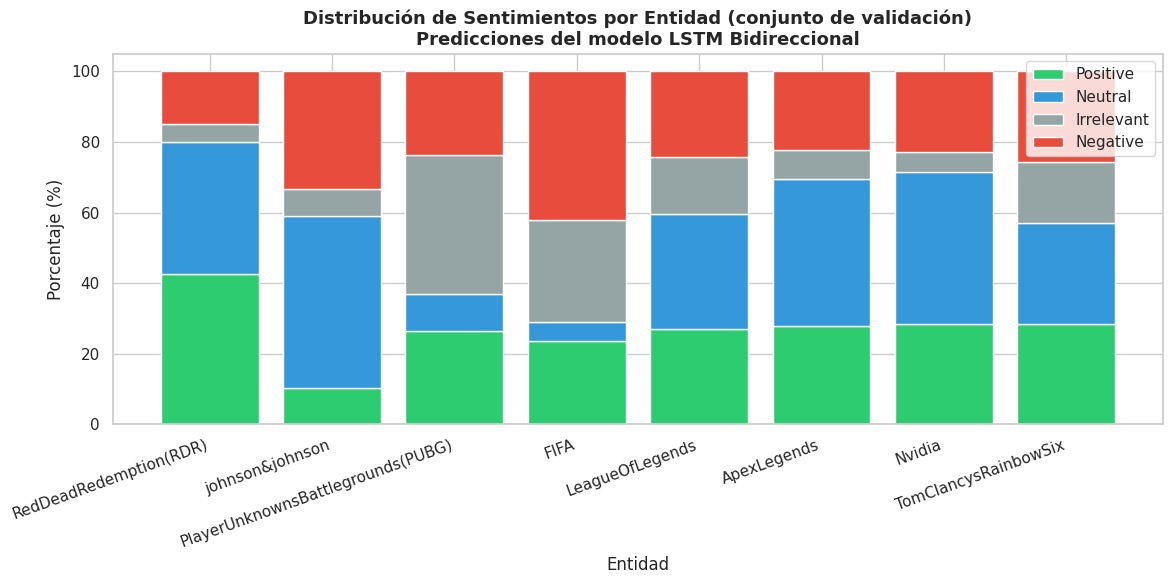


💼 INTERPRETACIÓN EMPRESARIAL:
   Este gráfico permite a las empresas ver de un vistazo
   cómo está el sentimiento hacia cada marca o producto en Twitter.
   Una barra con mucho rojo indica que esa entidad necesita atención.


In [37]:
# ─── Dashboard: Análisis de Sentimientos por Entidad ─────────────────────────
# Usamos los datos de validación con predicciones del modelo LSTM

val_results = val_df[['entity', 'sentiment', 'text']].copy()
val_results['predicted'] = label_encoder.inverse_transform(best_preds)

# Top 8 entidades por volumen en el conjunto de validación
top_8_entities = val_results['entity'].value_counts().head(8).index.tolist()
val_top = val_results[val_results['entity'].isin(top_8_entities)]

# Calcular % positivo y negativo por entidad
def sentiment_breakdown(df):
    total = len(df)
    pos   = (df['predicted'] == 'Positive').sum()  / total * 100
    neg   = (df['predicted'] == 'Negative').sum()  / total * 100
    neu   = (df['predicted'] == 'Neutral').sum()   / total * 100
    irr   = (df['predicted'] == 'Irrelevant').sum()/ total * 100
    return {'Positive': pos, 'Negative': neg, 'Neutral': neu, 'Irrelevant': irr}

entity_sentiment = pd.DataFrame({
    entity: sentiment_breakdown(val_top[val_top['entity'] == entity])
    for entity in top_8_entities
}).T

# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c',
          'Neutral': '#3498db', 'Irrelevant': '#95a5a6'}

bottom = np.zeros(len(top_8_entities))
for sentiment in ['Positive', 'Neutral', 'Irrelevant', 'Negative']:
    values = entity_sentiment[sentiment].values
    ax.bar(top_8_entities, values, bottom=bottom,
           label=sentiment, color=colors[sentiment], edgecolor='white')
    bottom += values

ax.set_title('Distribución de Sentimientos por Entidad (conjunto de validación)\n'
             'Predicciones del modelo LSTM Bidireccional',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Entidad')
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(top_8_entities, rotation=20, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print('\n💼 INTERPRETACIÓN EMPRESARIAL:')
print('   Este gráfico permite a las empresas ver de un vistazo')
print('   cómo está el sentimiento hacia cada marca o producto en Twitter.')
print('   Una barra con mucho rojo indica que esa entidad necesita atención.')

---
## 🎯 Sección 13 — Conclusiones y Próximos Pasos

### ¿Qué aprendimos?

#### Sobre NLP y representación del lenguaje
- El texto debe **transformarse en vectores numéricos** para que una máquina lo procese
- Los **Word Embeddings** capturan relaciones semánticas entre palabras
- Las palabras similares quedan **cercanas en el espacio vectorial**

#### Sobre los modelos
- **SVM + TF-IDF**: sorprendentemente competitivo y muy rápido de entrenar
- **LSTM Bidireccional**: captura el orden y contexto de las palabras
- **GRU**: más eficiente que LSTM, resultados similares
- Los modelos de Deep Learning **aprenden sus propios embeddings** durante el entrenamiento

#### Limitaciones encontradas
- **Sarcasmo e ironía** siguen siendo el mayor reto
- El lenguaje de Twitter (slang, abreviaciones) reduce el rendimiento
- La clase **Neutral** e **Irrelevant** son más difíciles de separar
- Sin contexto cultural, muchos tweets se malinterpretan

### ¿Cómo mejorar este sistema?

| Mejora | Descripción | Impacto estimado |
|--------|-------------|------------------|
| **Fine-tuning de BERT** | Usar `bert-base-uncased` o `twitter-roberta-base` | +10-15% accuracy |
| **Más datos de entrenamiento** | Agregar más tweets anotados | +5-10% |
| **Detección de sarcasmo** | Modelo auxiliar especializado | Mejora casos difíciles |
| **Embeddings pre-entrenados** | GloVe Twitter 200d o FastText | +3-7% |
| **Data augmentation** | Back-translation, sinonimización | +3-5% |

### El estado del arte actual (2024)

Los mejores modelos de análisis de sentimientos en Twitter usan:
- **RoBERTa-base-twitter** (entrenado específicamente en tweets)
- **GPT-4 con few-shot prompting**
- **Modelos multimodales** que analizan texto + emojis + imágenes juntos


In [38]:
# ─── Resumen ejecutivo final ─────────────────────────────────────────────────
print('='*65)
print('  🎯 RESUMEN EJECUTIVO — TWITTER SENTIMENT ANALYSIS')
print('='*65)
print()
print('📊 DATASET:')
print(f'   • Tweets de entrenamiento: {len(train_df):,}')
print(f'   • Tweets de validación  : {len(val_df):,}')
print(f'   • Clases                : 4 (Positive, Negative, Neutral, Irrelevant)')
print(f'   • Entidades únicas      : {train_df["entity"].nunique()}')
print()
print('🤖 MODELOS ENTRENADOS Y RESULTADOS:')
ranking = sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True)
for i, (name, m) in enumerate(ranking, 1):
    medal = ['🥇','🥈','🥉','4️⃣','5️⃣'][i-1]
    print(f'   {medal} {name:30} Acc={m["accuracy"]:.4f}  F1={m["f1"]:.4f}')
print()
print('💡 PRINCIPALES APRENDIZAJES:')
print('   1. El lenguaje humano es complejo, contextual y cultural')
print('   2. Las RNN capturan el orden temporal del texto (las palabras importan como secuencia)')
print('   3. Los embeddings permiten hacer matemáticas con el significado')
print('   4. El sarcasmo y la ironía siguen siendo el mayor reto del NLP')
print('   5. Los Transformers (BERT/GPT) representan el estado del arte actual')
print()
print('🚀 PRÓXIMO PASO RECOMENDADO:')
print('   Fine-tuning de cardiffnlp/twitter-roberta-base-sentiment')
print('   (modelo pre-entrenado específicamente en 58M tweets)')
print('='*65)

  🎯 RESUMEN EJECUTIVO — TWITTER SENTIMENT ANALYSIS

📊 DATASET:
   • Tweets de entrenamiento: 72,171
   • Tweets de validación  : 999
   • Clases                : 4 (Positive, Negative, Neutral, Irrelevant)
   • Entidades únicas      : 32

🤖 MODELOS ENTRENADOS Y RESULTADOS:
   🥇 SVM                            Acc=0.9540  F1=0.9540
   🥈 LSTM Bidireccional             Acc=0.9229  F1=0.9230
   🥉 Árbol de Decisión              Acc=0.5235  F1=0.5062
   4️⃣ Random Forest                  Acc=0.5065  F1=0.4465

💡 PRINCIPALES APRENDIZAJES:
   1. El lenguaje humano es complejo, contextual y cultural
   2. Las RNN capturan el orden temporal del texto (las palabras importan como secuencia)
   3. Los embeddings permiten hacer matemáticas con el significado
   4. El sarcasmo y la ironía siguen siendo el mayor reto del NLP
   5. Los Transformers (BERT/GPT) representan el estado del arte actual

🚀 PRÓXIMO PASO RECOMENDADO:
   Fine-tuning de cardiffnlp/twitter-roberta-base-sentiment
   (modelo pre-entr

In [39]:
# ─── Sistema de predicción interactivo ───────────────────────────────────────
print('🔮 SISTEMA DE PREDICCIÓN INTERACTIVO')
print('Escribe un tweet y el modelo predecirá su sentimiento')
print('(Escribe "salir" para terminar)')
print()

while True:
    user_input = input('Tweet: ')
    if user_input.lower() in ('salir', 'exit', 'quit', ''):
        print('¡Hasta luego!')
        break

    preds = predict_sentiment([user_input], lstm_model, tokenizer, label_encoder, MAX_LEN)
    text, sentiment, confidence = preds[0]

    icon = {'Positive':'😊','Negative':'😠','Neutral':'😐','Irrelevant':'🔕'}[sentiment]
    print(f'\n  Resultado: {icon} {sentiment} (confianza: {confidence*100:.1f}%)')
    print(f'  Texto limpio: "{clean_tweet(user_input)}"')
    print()

🔮 SISTEMA DE PREDICCIÓN INTERACTIVO
Escribe un tweet y el modelo predecirá su sentimiento
(Escribe "salir" para terminar)

Tweet: Genial, otro lunes en la oficina que pereza.

  Resultado: 😠 Negative (confianza: 99.9%)
  Texto limpio: "genial otro lunes oficina que pereza"

Tweet: Oh dios mio, que hermosa criatura.

  Resultado: 😠 Negative (confianza: 99.9%)
  Texto limpio: "dios mio que hermosa criatura"

Tweet: que linda te ves hoy con el vestido rojo 

  Resultado: 😠 Negative (confianza: 100.0%)
  Texto limpio: "que linda f hoy con vestido rojo"



KeyboardInterrupt: Interrupted by user